Classes: ['Hijaz', 'Nahawand', 'Saba']

✅ Random Forest trained.

[RF — Validation] Accuracy: 0.920
              precision    recall  f1-score   support

       Hijaz       0.82      1.00      0.90         9
    Nahawand       1.00      0.88      0.93         8
        Saba       1.00      0.88      0.93         8

    accuracy                           0.92        25
   macro avg       0.94      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25



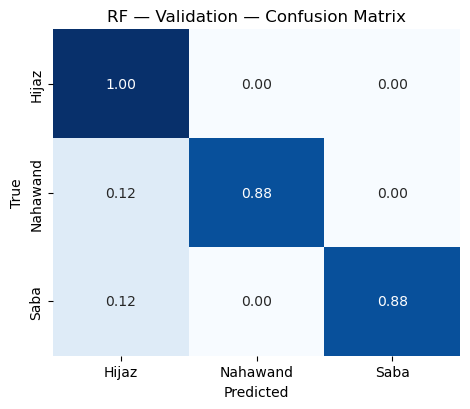


[RF — Test] Accuracy: 0.923
              precision    recall  f1-score   support

       Hijaz       0.88      0.88      0.88         8
    Nahawand       0.90      1.00      0.95         9
        Saba       1.00      0.89      0.94         9

    accuracy                           0.92        26
   macro avg       0.92      0.92      0.92        26
weighted avg       0.93      0.92      0.92        26



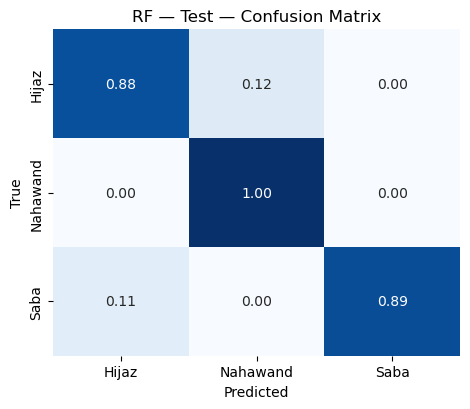

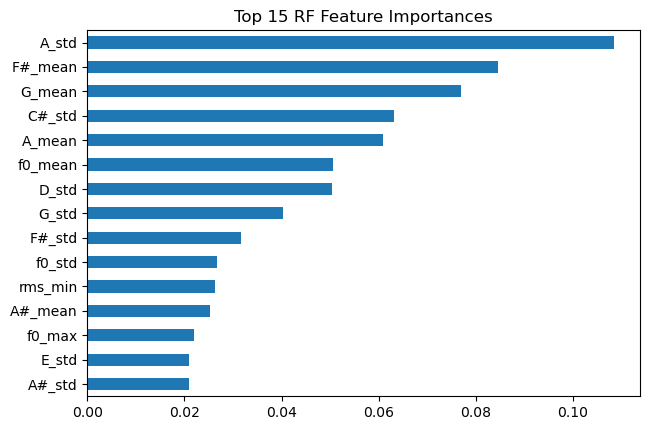

💾 Saved RF → C:\Users\nabal\Documents\FYP\models_baselines\rf_engineered.joblib

✅ SVM (RBF) trained.

[SVM — Validation] Accuracy: 0.920
              precision    recall  f1-score   support

       Hijaz       0.90      1.00      0.95         9
    Nahawand       1.00      0.75      0.86         8
        Saba       0.89      1.00      0.94         8

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25



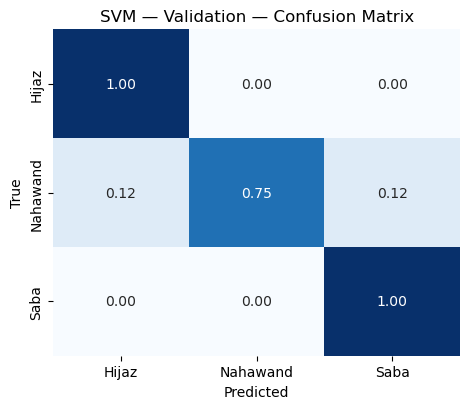


[SVM — Test] Accuracy: 0.885
              precision    recall  f1-score   support

       Hijaz       0.88      0.88      0.88         8
    Nahawand       0.80      0.89      0.84         9
        Saba       1.00      0.89      0.94         9

    accuracy                           0.88        26
   macro avg       0.89      0.88      0.89        26
weighted avg       0.89      0.88      0.89        26



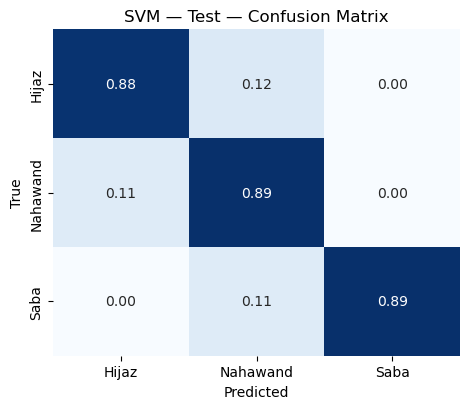

💾 Saved SVM → C:\Users\nabal\Documents\FYP\models_baselines\svm_engineered.joblib

✅ XGBoost trained.

[XGBoost — Validation] Accuracy: 0.880
              precision    recall  f1-score   support

       Hijaz       0.82      1.00      0.90         9
    Nahawand       1.00      0.75      0.86         8
        Saba       0.88      0.88      0.88         8

    accuracy                           0.88        25
   macro avg       0.90      0.88      0.88        25
weighted avg       0.89      0.88      0.88        25



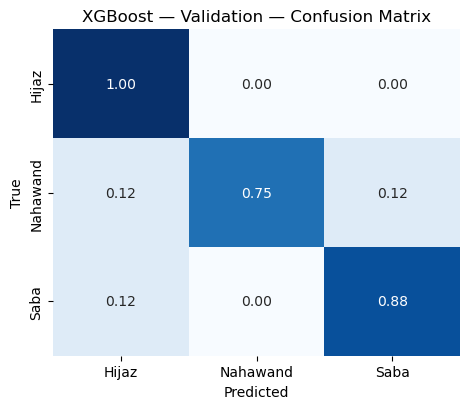


[XGBoost — Test] Accuracy: 0.885
              precision    recall  f1-score   support

       Hijaz       0.86      0.75      0.80         8
    Nahawand       0.82      1.00      0.90         9
        Saba       1.00      0.89      0.94         9

    accuracy                           0.88        26
   macro avg       0.89      0.88      0.88        26
weighted avg       0.89      0.88      0.88        26



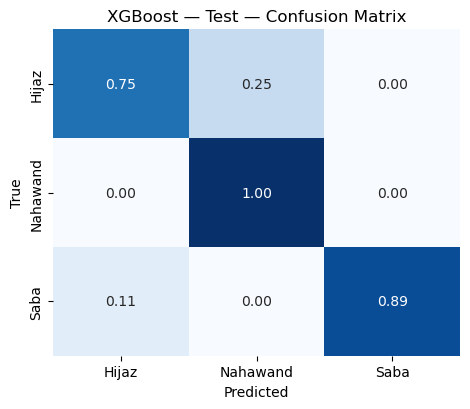

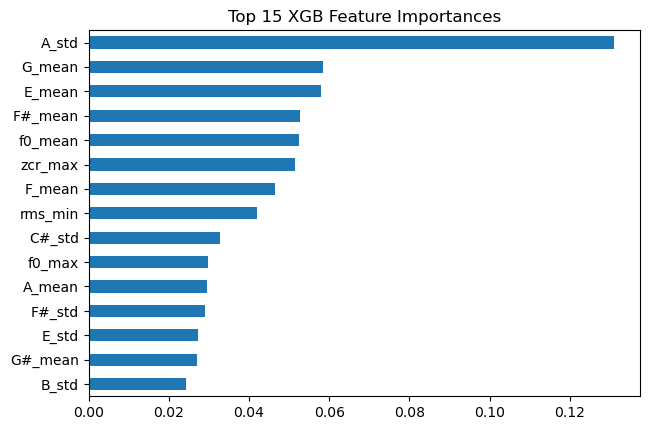

💾 Saved XGB → C:\Users\nabal\Documents\FYP\models_baselines\xgb_engineered.joblib

============== Summary — Accuracies ==============
RF_val    : 0.920
RF_test   : 0.923
SVM_val   : 0.920
SVM_test  : 0.885
XGB_val   : 0.880
XGB_test  : 0.885


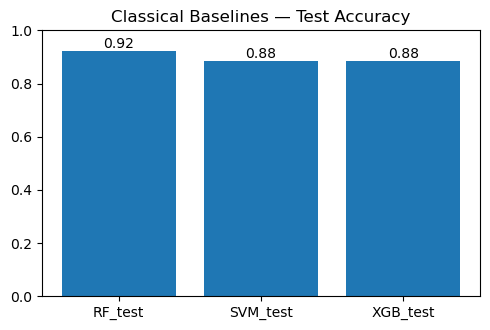

In [ ]:
# ==== Stage 4 (combined): RF + SVM + XGBoost on engineered features ====
import os, joblib, numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

# --- Paths
BASE = r"C:\Users\nabal\Documents\FYP"
FEAT_DIR = os.path.join(BASE, "features_engineered_v1")
MODEL_DIR = os.path.join(BASE, "models_baselines"); os.makedirs(MODEL_DIR, exist_ok=True)

# --- Load features
train = pd.read_csv(os.path.join(FEAT_DIR, "train.csv"))
val   = pd.read_csv(os.path.join(FEAT_DIR, "val.csv"))
test  = pd.read_csv(os.path.join(FEAT_DIR, "test.csv"))

# --- Build X/y (drop non-feature cols)
NONFEATS = ["file_path","maqam","reciter"]
feat_cols = [c for c in train.columns if c not in NONFEATS]

X_tr, y_tr = train[feat_cols].values, train["maqam"].values
X_va, y_va = val[feat_cols].values,   val["maqam"].values
X_te, y_te = test[feat_cols].values,  test["maqam"].values

# --- Encode labels using TRAIN only (consistent mapping)
le = LabelEncoder().fit(y_tr)
y_tr_i, y_va_i, y_te_i = le.transform(y_tr), le.transform(y_va), le.transform(y_te)
classes = list(le.classes_)
print("Classes:", classes)

def evaluate(model, X, y_true, title):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n[{title}] Accuracy: {acc:.3f}")
    print(classification_report(y_true, y_pred, target_names=classes))
    # Confusion matrix (row-normalized)
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(4.8,4.2))
    sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=classes, yticklabels=classes,
                fmt=".2f", cbar=False)
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()
    return acc

results = {}

# -------------------------
# 1) Random Forest (bagging)
# -------------------------
rf = Pipeline([
    ("scaler", StandardScaler()),  # harmless for trees, keeps parity with SVM/XGB pipelines
    ("rf", RandomForestClassifier(
        n_estimators=600, max_depth=None, min_samples_leaf=1,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1))
])
rf.fit(X_tr, y_tr_i)
print("\n✅ Random Forest trained.")
results["RF_val"]  = evaluate(rf, X_va, y_va_i, "RF — Validation")
results["RF_test"] = evaluate(rf, X_te, y_te_i, "RF — Test")

# RF feature importances (from the RF step)
rf_model = rf.named_steps["rf"]
rf_imp = pd.Series(rf_model.feature_importances_, index=feat_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(6.6,4.4))
rf_imp.iloc[::-1].plot(kind="barh")
plt.title("Top 15 RF Feature Importances"); plt.tight_layout(); plt.show()

# Save RF
joblib.dump({"pipeline": rf, "label_encoder": le, "feat_cols": feat_cols},
            os.path.join(MODEL_DIR, "rf_engineered.joblib"))
print("💾 Saved RF →", os.path.join(MODEL_DIR, "rf_engineered.joblib"))

# -------------------------
# 2) SVM (RBF kernel)
# -------------------------
svm = Pipeline([
    ("scaler", StandardScaler()),  # REQUIRED for SVM
    ("svm", SVC(kernel="rbf", C=10, gamma="scale",
                class_weight="balanced", probability=True, random_state=42))
])
svm.fit(X_tr, y_tr_i)
print("\n✅ SVM (RBF) trained.")
results["SVM_val"]  = evaluate(svm, X_va, y_va_i, "SVM — Validation")
results["SVM_test"] = evaluate(svm, X_te, y_te_i, "SVM — Test")

joblib.dump({"pipeline": svm, "label_encoder": le, "feat_cols": feat_cols},
            os.path.join(MODEL_DIR, "svm_engineered.joblib"))
print("💾 Saved SVM →", os.path.join(MODEL_DIR, "svm_engineered.joblib"))

# -------------------------
# 3) XGBoost (gradient boosting)
# -------------------------
xgb_available = True
try:
    from xgboost import XGBClassifier
    xgb = Pipeline([
        ("scaler", StandardScaler()),  # not strictly needed for trees, but fine for parity
        ("xgb", XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.9, colsample_bytree=0.9,
            objective="multi:softprob", num_class=len(classes),
            reg_lambda=1.0, random_state=42, n_jobs=-1
        ))
    ])
    xgb.fit(X_tr, y_tr_i)
    print("\n✅ XGBoost trained.")
    results["XGB_val"]  = evaluate(xgb, X_va, y_va_i, "XGBoost — Validation")
    results["XGB_test"] = evaluate(xgb, X_te, y_te_i, "XGBoost — Test")

    # XGB feature importances
    xgb_model = xgb.named_steps["xgb"]
    try:
        xgb_imp = pd.Series(xgb_model.feature_importances_, index=feat_cols) \
                    .sort_values(ascending=False).head(15)
        plt.figure(figsize=(6.6,4.4))
        xgb_imp.iloc[::-1].plot(kind="barh")
        plt.title("Top 15 XGB Feature Importances"); plt.tight_layout(); plt.show()
    except Exception as e:
        print("XGB importance not available:", e)

    joblib.dump({"pipeline": xgb, "label_encoder": le, "feat_cols": feat_cols},
                os.path.join(MODEL_DIR, "xgb_engineered.joblib"))
    print("💾 Saved XGB →", os.path.join(MODEL_DIR, "xgb_engineered.joblib"))

except Exception as e:
    xgb_available = False
    print("\n⚠️ XGBoost not available:", repr(e))
    print("   → You can install it with:  pip install xgboost")

# -------------------------
# Summary table
# -------------------------
print("\n============== Summary — Accuracies ==============")
for k,v in results.items():
    print(f"{k:10s}: {v:.3f}")

# Optional: quick bar chart (test accuracies only)
test_keys = [k for k in results.keys() if k.endswith("_test")]
plt.figure(figsize=(5,3.4))
plt.bar(test_keys, [results[k] for k in test_keys])
plt.title("Classical Baselines — Test Accuracy")
plt.ylim(0,1.0)
for i,k in enumerate(test_keys):
    plt.text(i, results[k]+0.01, f"{results[k]:.2f}", ha="center")
plt.tight_layout(); plt.show()
